Final Model Comparison + Confusion Matrix + Model Save

In [9]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None


In [10]:
project_root = Path('..').resolve()
processed_data_dir = project_root / 'data' / 'processed'
resampled_data_dir = project_root / 'data' / 'imbalanced'
reports_dir = project_root / 'reports'
figures_dir = reports_dir / 'figures'
model_output_dir = project_root / 'model'
for output_dir in [reports_dir, figures_dir, model_output_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

feature_columns = [
    'inter_api_access_duration(sec)', 'api_access_uniqueness', 'sequence_length(count)',
    'vsession_duration(min)', 'ip_type', 'num_sessions', 'num_users',
    'num_unique_apis', 'source', 'failed_auth_count', 'token_reuse_ratio',
    'status_4xx_ratio', 'status_5xx_ratio'
]
target_column = 'attack_class'
categorical_feature_columns = ['ip_type', 'source']
numerical_feature_columns = [col for col in feature_columns if col not in categorical_feature_columns]


In [11]:
stage3_best_combo_candidates = [
    reports_dir / '03_scaling_best_combo.csv',
    reports_dir / 'stage_b_best_combo.csv'
]
stage3_best_combo_path = next((p for p in stage3_best_combo_candidates if p.exists()), None)
if stage3_best_combo_path is None:
    raise FileNotFoundError('Missing Stage 3 best-combo file. Expected one of: 03_scaling_best_combo.csv, stage_b_best_combo.csv')
stage_b_best_combo_row = pd.read_csv(stage3_best_combo_path).iloc[0]
stage_a_top2_candidates = [
    reports_dir / '02_resampling_top2_resampling.csv',
    reports_dir / 'stage_a_top2_resampling.csv'
]
stage_a_top2_path = next((p for p in stage_a_top2_candidates if p.exists()), None)
if stage_a_top2_path is None:
    raise FileNotFoundError('Missing top-2 resampling file. Expected one of: 02_resampling_top2_resampling.csv, stage_a_top2_resampling.csv')
stage_a_top2_resampling_df = pd.read_csv(stage_a_top2_path).iloc[0]

if 'best_two_resampling_methods' in stage_a_top2_resampling_df.index:
    candidate_resampling_methods = [x.strip() for x in str(stage_a_top2_resampling_df['best_two_resampling_methods']).split(',') if x.strip()]
elif 'top2_resampling' in stage_a_top2_resampling_df.index:
    candidate_resampling_methods = [x.strip() for x in str(stage_a_top2_resampling_df['top2_resampling']).split(',') if x.strip()]
else:
    candidate_resampling_methods = [str(stage_b_best_combo_row['best_resampling'])]

# Include Stage B winner as fallback and remove duplicates while preserving order
candidate_resampling_methods = list(dict.fromkeys(candidate_resampling_methods + [str(stage_b_best_combo_row['best_resampling'])]))

allowed_resampling_methods = {'none', 'oversampling', 'undersampling', 'smote'}
candidate_resampling_methods = [m for m in candidate_resampling_methods if m in allowed_resampling_methods]
if not candidate_resampling_methods:
    raise ValueError('No valid candidate resampling methods available for Stage C after filtering.')
candidate_scaling_methods = ['none', 'minmax', 'standard']

evaluation_test_features = pd.read_csv(processed_data_dir / 'X_test.csv')
evaluation_test_labels_df = pd.read_csv(processed_data_dir / 'y_test.csv')
evaluation_test_labels = (
    evaluation_test_labels_df[target_column]
    if target_column in evaluation_test_labels_df.columns
    else evaluation_test_labels_df.iloc[:, 0]
)

print('resampling methods    :', candidate_resampling_methods)
print('scaling methods       :', candidate_scaling_methods)
print('Evaluation test shape :', evaluation_test_features.shape)


resampling methods    : ['undersampling', 'oversampling']
scaling methods       : ['none', 'minmax', 'standard']
Evaluation test shape : (1200, 13)


In [12]:
def build_feature_preprocessor(scaling_method):
    if scaling_method == 'none':
        numerical_transform_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    elif scaling_method == 'minmax':
        numerical_transform_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', MinMaxScaler())])
    else:
        numerical_transform_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

    return ColumnTransformer([
        ('num', numerical_transform_pipeline, numerical_feature_columns),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_feature_columns)
    ], sparse_threshold=0.0)


In [13]:
candidate_models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=5000, solver='lbfgs', class_weight='balanced'),
    'NaiveBayes': GaussianNB(),
}
if XGBClassifier is not None:
    candidate_models['XGBoost'] = XGBClassifier(eval_metric='mlogloss', random_state=42, n_estimators=250, max_depth=6, learning_rate=0.08)

print('Models to evaluate:', list(candidate_models.keys()))


Models to evaluate: ['RandomForest', 'SVM', 'LogisticRegression', 'NaiveBayes', 'XGBoost']


Initialize Result Registry


In [17]:
model_evaluation_rows = []
trained_model_registry = {}

def load_resampled_training_data(resampling_method):
    training_features = pd.read_csv(resampled_data_dir / f'X_{resampling_method}.csv')
    if not set(feature_columns).issubset(set(training_features.columns)):
        if training_features.shape[1] >= len(feature_columns):
            training_features = training_features.iloc[:, :len(feature_columns)].copy()
            training_features.columns = feature_columns
        else:
            missing_columns = sorted(set(feature_columns) - set(training_features.columns))
            raise ValueError(f'Resampled file for {resampling_method} is missing required columns: {missing_columns}')

    training_labels_df = pd.read_csv(resampled_data_dir / f'y_{resampling_method}.csv')
    training_labels = training_labels_df[target_column] if target_column in training_labels_df.columns else training_labels_df.iloc[:, 0]
    return training_features, training_labels

def evaluate_model_with_combo(model_name, estimator, resampling_method, scaling_method):
    training_features, training_labels = load_resampled_training_data(resampling_method)
    training_pipeline = Pipeline([
        ('preprocessor', build_feature_preprocessor(scaling_method)),
        ('model', estimator)
    ])

    if model_name == 'XGBoost':
        label_encoder = LabelEncoder()
        encoded_training_labels = label_encoder.fit_transform(training_labels)
        training_pipeline.fit(training_features, encoded_training_labels)
        encoded_predictions = training_pipeline.predict(evaluation_test_features)
        test_predictions = label_encoder.inverse_transform(encoded_predictions.astype(int))
    else:
        training_pipeline.fit(training_features, training_labels)
        test_predictions = training_pipeline.predict(evaluation_test_features)

    return {
        'resampling': resampling_method,
        'scaling': scaling_method,
        'model': model_name,
        'accuracy': round(accuracy_score(evaluation_test_labels, test_predictions), 4),
        'macro_precision': round(precision_score(evaluation_test_labels, test_predictions, average='macro', zero_division=0), 4),
        'macro_recall': round(recall_score(evaluation_test_labels, test_predictions, average='macro', zero_division=0), 4),
        'macro_f1': round(f1_score(evaluation_test_labels, test_predictions, average='macro', zero_division=0), 4),
    }, training_pipeline, test_predictions

def register_best_result_for_model(model_name, result_rows):
    if not result_rows:
        raise ValueError(f'No results were produced for {model_name}.')
    model_result_df = pd.DataFrame(result_rows).sort_values(['macro_f1', 'macro_recall'], ascending=False).reset_index(drop=True)
    best_row = model_result_df.iloc[0].to_dict()
    key = (best_row['resampling'], best_row['scaling'])
    best_pipeline, best_predictions = pipeline_cache[key]

    model_evaluation_rows.append(best_row)
    trained_model_registry[model_name] = (best_pipeline, best_predictions, best_row)

    print(f"Best for {model_name}: resampling={best_row['resampling']}, scaling={best_row['scaling']}, macro_f1={best_row['macro_f1']}")
    return model_result_df

print('Result registry initialized. Each model cell now searches best (resampling, scaling) combo for that model.')


Result registry initialized. Each model cell now searches best (resampling, scaling) combo for that model.


Train and Evaluate RandomForest


In [18]:
pipeline_cache = {}
random_forest_rows = []

for resampling_method in candidate_resampling_methods:
    for scaling_method in candidate_scaling_methods:
        row, trained_pipeline, predictions = evaluate_model_with_combo(
            'RandomForest',
            RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
            resampling_method,
            scaling_method
        )
        random_forest_rows.append(row)
        pipeline_cache[(resampling_method, scaling_method)] = (trained_pipeline, predictions)

random_forest_result_df = register_best_result_for_model('RandomForest', random_forest_rows)
random_forest_result_df


Best for RandomForest: resampling=undersampling, scaling=none, macro_f1=0.9973


,resampling,scaling,model,accuracy,macro_precision,macro_recall,macro_f1
0,undersampling,none,RandomForest,0.9983,0.9973,0.9973,0.9973
1,undersampling,minmax,RandomForest,0.9983,0.9973,0.9973,0.9973
2,undersampling,standard,RandomForest,0.9983,0.9973,0.9973,0.9973
3,oversampling,none,RandomForest,0.9958,0.9950,0.9925,0.9937
4,oversampling,minmax,RandomForest,0.9958,0.9950,0.9925,0.9937
5,oversampling,standard,RandomForest,0.9958,0.9950,0.9925,0.9937


Train and Evaluate SVM


In [19]:
pipeline_cache = {}
svm_rows = []

for resampling_method in candidate_resampling_methods:
    for scaling_method in candidate_scaling_methods:
        row, trained_pipeline, predictions = evaluate_model_with_combo(
            'SVM',
            SVC(probability=True, class_weight='balanced', random_state=42),
            resampling_method,
            scaling_method
        )
        svm_rows.append(row)
        pipeline_cache[(resampling_method, scaling_method)] = (trained_pipeline, predictions) 

svm_result_df = register_best_result_for_model('SVM', svm_rows)
svm_result_df

Best for SVM: resampling=undersampling, scaling=standard, macro_f1=0.9927


,resampling,scaling,model,accuracy,macro_precision,macro_recall,macro_f1
0,undersampling,standard,SVM,0.9942,0.9917,0.9938,0.9927
1,oversampling,standard,SVM,0.9933,0.9906,0.9905,0.9906
2,undersampling,minmax,SVM,0.9917,0.9879,0.9911,0.9894
3,oversampling,minmax,SVM,0.9908,0.9867,0.9882,0.9873
4,oversampling,none,SVM,0.9033,0.8800,0.8962,0.8847
5,undersampling,none,SVM,0.8833,0.8594,0.8665,0.8600


Train and Evaluate LogisticRegression


In [20]:
pipeline_cache = {}
logistic_regression_rows = []

for resampling_method in candidate_resampling_methods:
    for scaling_method in candidate_scaling_methods:
        row, trained_pipeline, predictions = evaluate_model_with_combo(
            'LogisticRegression',
            LogisticRegression(max_iter=5000, solver='lbfgs', class_weight='balanced'),
            resampling_method,
            scaling_method
        )
        logistic_regression_rows.append(row)
        pipeline_cache[(resampling_method, scaling_method)] = (trained_pipeline, predictions)

logistic_regression_result_df = register_best_result_for_model('LogisticRegression', logistic_regression_rows)
logistic_regression_result_df


Best for LogisticRegression: resampling=undersampling, scaling=standard, macro_f1=0.9958


,resampling,scaling,model,accuracy,macro_precision,macro_recall,macro_f1
0,undersampling,standard,LogisticRegression,0.9967,0.9958,0.9957,0.9958
1,oversampling,standard,LogisticRegression,0.9950,0.9933,0.9938,0.9936
2,oversampling,none,LogisticRegression,0.9933,0.9896,0.9907,0.9902
3,oversampling,minmax,LogisticRegression,0.9917,0.9883,0.9907,0.9894
4,undersampling,minmax,LogisticRegression,0.9908,0.9867,0.9895,0.9880
5,undersampling,none,LogisticRegression,0.9908,0.9855,0.9880,0.9867


Train and Evaluate NaiveBayes


In [21]:
pipeline_cache = {}
naive_bayes_rows = []

for resampling_method in candidate_resampling_methods:
    for scaling_method in candidate_scaling_methods:
        row, trained_pipeline, predictions = evaluate_model_with_combo(
            'NaiveBayes',
            GaussianNB(),
            resampling_method,
            scaling_method
        )
        naive_bayes_rows.append(row)
        pipeline_cache[(resampling_method, scaling_method)] = (trained_pipeline, predictions)

naive_bayes_result_df = register_best_result_for_model('NaiveBayes', naive_bayes_rows)
naive_bayes_result_df


Best for NaiveBayes: resampling=oversampling, scaling=none, macro_f1=0.9965


,resampling,scaling,model,accuracy,macro_precision,macro_recall,macro_f1
0,oversampling,none,NaiveBayes,0.9975,0.9965,0.9965,0.9965
1,oversampling,minmax,NaiveBayes,0.9975,0.9965,0.9965,0.9965
2,oversampling,standard,NaiveBayes,0.9975,0.9965,0.9965,0.9965
3,undersampling,none,NaiveBayes,0.9967,0.9954,0.9961,0.9957
4,undersampling,minmax,NaiveBayes,0.9967,0.9954,0.9961,0.9957
5,undersampling,standard,NaiveBayes,0.9967,0.9954,0.9961,0.9957


Train and Evaluate XGBoost

In [22]:
if XGBClassifier is not None:
    pipeline_cache = {}
    xgboost_rows = []

    for resampling_method in candidate_resampling_methods:
        for scaling_method in candidate_scaling_methods:
            row, trained_pipeline, predictions = evaluate_model_with_combo(
                'XGBoost',
                XGBClassifier(eval_metric='mlogloss', random_state=42, n_estimators=250, max_depth=6, learning_rate=0.08),
                resampling_method,
                scaling_method
            )
            xgboost_rows.append(row)
            pipeline_cache[(resampling_method, scaling_method)] = (trained_pipeline, predictions)

    xgboost_result_df = register_best_result_for_model('XGBoost', xgboost_rows)
    xgboost_result_df
else:
    print('Skipped: XGBoost package is not available.')


Best for XGBoost: resampling=undersampling, scaling=none, macro_f1=0.9928


Build Final Stage C Ranking


In [23]:
if not model_evaluation_rows:
    raise ValueError('No model results found. Run at least one model-training cell first.')

stage_c_results_df = pd.DataFrame(model_evaluation_rows).sort_values(['macro_f1', 'macro_recall'], ascending=False).reset_index(drop=True)
winning_row = stage_c_results_df.iloc[0]
winning_model_name = winning_row['model']
winning_pipeline, winning_test_predictions, _ = trained_model_registry[winning_model_name]

stage_c_results_df

,resampling,scaling,model,accuracy,macro_precision,macro_recall,macro_f1
0,undersampling,none,RandomForest,0.9983,0.9973,0.9973,0.9973
1,oversampling,none,NaiveBayes,0.9975,0.9965,0.9965,0.9965
2,undersampling,standard,LogisticRegression,0.9967,0.9958,0.9957,0.9958
3,undersampling,none,XGBoost,0.9950,0.9929,0.9927,0.9928
4,undersampling,standard,SVM,0.9942,0.9917,0.9938,0.9927


Audit Class Distribution and Per-Class Metrics


In [24]:
if 'winning_test_predictions' not in globals():
    raise ValueError('Run the ranking cell first so winning predictions are available.')

test_class_distribution_df = (
    pd.Series(evaluation_test_labels)
    .value_counts(dropna=False)
    .rename_axis('class_label')
    .reset_index(name='test_support')
)
test_class_distribution_df['test_support_pct'] = (
    100 * test_class_distribution_df['test_support'] / test_class_distribution_df['test_support'].sum()
).round(2)

per_class_metrics_dict = classification_report(
    evaluation_test_labels,
    winning_test_predictions,
    output_dict=True,
    zero_division=0
)

per_class_metrics_df = pd.DataFrame(per_class_metrics_dict).T
per_class_metrics_df = per_class_metrics_df.loc[
    ~per_class_metrics_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])
].reset_index().rename(columns={'index': 'class_label'})

for metric_col in ['precision', 'recall', 'f1-score']:
    per_class_metrics_df[metric_col] = per_class_metrics_df[metric_col].round(4)
per_class_metrics_df['support'] = per_class_metrics_df['support'].astype(int)

class_audit_df = per_class_metrics_df.merge(
    test_class_distribution_df,
    on='class_label',
    how='left'
).sort_values('f1-score', ascending=True).reset_index(drop=True)

print('Winning model:', winning_model_name)
print('Lowest-F1 classes first:')
display(class_audit_df)

hardest_class_row = class_audit_df.iloc[0]
print(
    'Most difficult class currently: ' + str(hardest_class_row['class_label']) +
    ' | F1=' + format(float(hardest_class_row['f1-score']), '.4f') +
    ', Recall=' + format(float(hardest_class_row['recall']), '.4f') +
    ', Support=' + str(int(hardest_class_row['support']))
)


Winning model: RandomForest
Lowest-F1 classes first:


,class_label,precision,recall,f1-score,support,test_support,test_support_pct
0,token_abuse,0.9939,0.9939,0.9939,163,163,13.58
1,bruteforce,0.9953,0.9953,0.9953,214,214,17.83
2,flood,1.0000,1.0000,1.0000,188,188,15.67
3,normal,1.0000,1.0000,1.0000,635,635,52.92


Most difficult class currently: token_abuse | F1=0.9939, Recall=0.9939, Support=163


Save Reports and Final Model


In [25]:
stage_c_results_df.to_csv(reports_dir / 'model_comparison.csv', index=False)
stage_c_results_df.head(1).to_csv(reports_dir / 'model_results.csv', index=False)

stage_a_top2_candidates = [
    reports_dir / '02_resampling_top2_resampling.csv',
    reports_dir / 'stage_a_top2_resampling.csv'
]
stage_a_top2_path = next((p for p in stage_a_top2_candidates if p.exists()), None)
if stage_a_top2_path is None:
    raise FileNotFoundError('Missing top-2 resampling file. Expected one of: 02_resampling_top2_resampling.csv, stage_a_top2_resampling.csv')
stage_a_top2_row = pd.read_csv(stage_a_top2_path).iloc[0]
if 'top2_resampling' in stage_a_top2_row.index:
    top2_resampling_methods = stage_a_top2_row['top2_resampling']
elif 'best_two_resampling_methods' in stage_a_top2_row.index:
    top2_resampling_methods = stage_a_top2_row['best_two_resampling_methods']
else:
    top2_resampling_methods = f"{stage_a_top2_row.get('best_method_rank_1', '')},{stage_a_top2_row.get('best_method_rank_2', '')}"

pd.DataFrame([{
    'top2_resampling': top2_resampling_methods,
    'best_resampling': winning_row['resampling'],
    'best_scaling': winning_row['scaling'],
    'best_model': winning_model_name
}]).to_csv(reports_dir / 'final_selection_summary.csv', index=False)

classification_report_text = classification_report(evaluation_test_labels, winning_test_predictions, digits=4)
(reports_dir / 'classification_report.txt').write_text(classification_report_text, encoding='utf-8')

joblib.dump(winning_pipeline, model_output_dir / 'api_security_pipeline.pkl')

print('Saved: model_comparison.csv, model_results.csv, final_selection_summary.csv')
print('Saved: classification_report.txt and api_security_pipeline.pkl')


Saved: model_comparison.csv, model_results.csv, final_selection_summary.csv
Saved: classification_report.txt and api_security_pipeline.pkl


Plot Confusion Matrix and Macro-F1 Chart


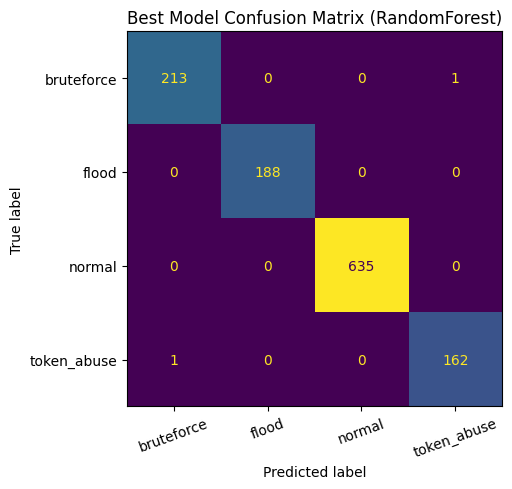

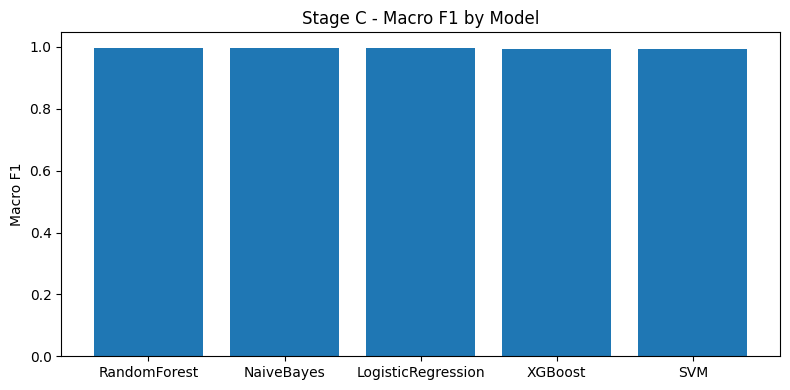

      resampling   scaling               model  accuracy  macro_precision  \
0  undersampling      none        RandomForest    0.9983           0.9973   
1   oversampling      none          NaiveBayes    0.9975           0.9965   
2  undersampling  standard  LogisticRegression    0.9967           0.9958   
3  undersampling      none             XGBoost    0.9950           0.9929   
4  undersampling  standard                 SVM    0.9942           0.9917   

   macro_recall  macro_f1  
0        0.9973    0.9973  
1        0.9965    0.9965  
2        0.9957    0.9958  
3        0.9927    0.9928  
4        0.9938    0.9927  
----------------------------------------------------------------------------------------------

Winning model: RandomForest
              precision    recall  f1-score   support

  bruteforce     0.9953    0.9953    0.9953       214
       flood     1.0000    1.0000    1.0000       188
      normal     1.0000    1.0000    1.0000       635
 token_abuse     0.9939    0

In [30]:
confusion_matrix_values = confusion_matrix(evaluation_test_labels, winning_test_predictions, labels=sorted(evaluation_test_labels.unique()))
figure, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix_values, display_labels=sorted(evaluation_test_labels.unique())).plot(ax=axis, xticks_rotation=20, colorbar=False)
plt.title(f'Best Model Confusion Matrix ({winning_model_name})')
plt.tight_layout()
plt.savefig(figures_dir / 'model_comparison_confusion_matrix.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(stage_c_results_df['model'], stage_c_results_df['macro_f1'])
plt.title('Stage C - Macro F1 by Model')
plt.ylabel('Macro F1')
plt.tight_layout()
plt.savefig(figures_dir / 'model_comparison_macro_f1.png', dpi=160)
plt.show()

print(stage_c_results_df)
print('----------------------------------------------------------------------------------------------')
print('')
print('Winning model:', winning_model_name)
print(classification_report_text)
print('----------------------------------------------------------------------------------------------')
print('Saved final model, reports, and figures for model comparison.')
